# Aufgabe 5
## Bestimmung der Werte für Verdampfungswärme mit Fit
FÜr Aufgabe 5 sollen für aus den Messwerten die Verdampfungswärme, mittels der Clausius-Clapeyron-Gleichung, ermitteln. DIese lautet wie folgt:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \cdot \Delta V_m}$$
Wenn man das $dT$ auf die andere Seite zieht so kann man beide Seiten integrieren um die Differentialgelichung zu lösen. 
$$\int dp_s = \int \frac{Q_{23}}{T \cdot \Delta V_m} dT$$
Löst man beide integrale so kommt man auf die folgende Gleichung:
$$p_s(T) = \frac{Q_{23}}{\Delta V_m} \cdot \ln(T) + C$$
Diese gleichung kann nun mit dem Python Modul `scipy.optimize.curve_fit`angepasst werden und es kann der Wert für $Q_{23}$ bestimmt werden.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import numpy as np
import matplotlib.pyplot as plt

# Daten für die Sättigungsdampfdrucke von Wasser bei verschiedenen Temperaturen
# T in Celsius, p_s in Pascal
T = np.array([31.5, 34.4, 37.5, 40.5, 43.5, 46.5])
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])    # Sättigungsdampfdrucke in Pa

# Umwandlung von Celsius in Kelvin
T = T + 273.15  # Umrechnung in Kelvin

# Gaskonstante
R = 8.314  # J/mol·K







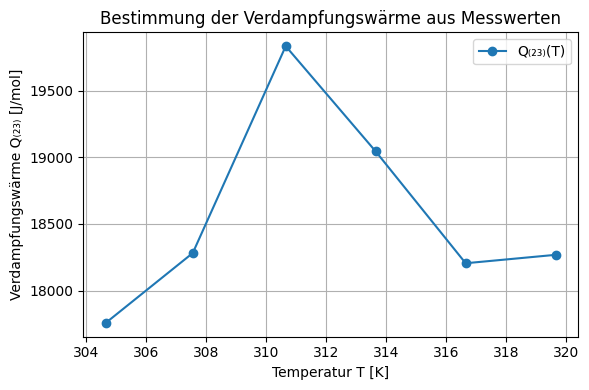

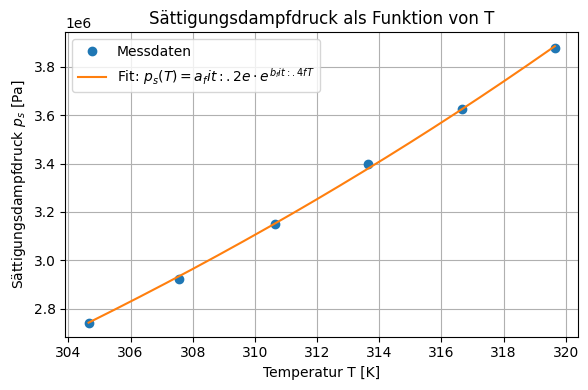

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Daten für die Sättigungsdampfdrucke von Wasser bei verschiedenen Temperaturen
# T in Celsius, p_s in Pascal
T = np.array([31.5, 34.4, 37.5, 40.5, 43.5, 46.5])
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])    # Sättigungsdampfdrucke in Pa

# Umwandlung von Celsius in Kelvin
T = T + 273.15  # Umrechnung in Kelvin

# Gaskonstante in J/mol·K
R = 8.314

# 📈 dp_s/dT numerisch (zentrale Differenz)
dp_dT = np.zeros_like(p_s, dtype=float)
dp_dT[1:-1] = (p_s[2:] - p_s[:-2]) / (T[2:] - T[:-2])
dp_dT[0] = (p_s[1] - p_s[0]) / (T[1] - T[0])       # einseitige Ableitung
dp_dT[-1] = (p_s[-1] - p_s[-2]) / (T[-1] - T[-2])

# 🔬 Clausius-Clapeyron: Q = R * T^2 / p_s * dp/dT
Q_23 = R * T**2 / p_s * dp_dT

# 📊 Plot: Q_23 über T
plt.figure(figsize=(6, 4))
plt.plot(T, Q_23, 'o-', label="Q₍₂₃₎(T)")
plt.xlabel("Temperatur T [K]")
plt.ylabel("Verdampfungswärme Q₍₂₃₎ [J/mol]")
plt.title("Bestimmung der Verdampfungswärme aus Messwerten")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📈 Plot: p_s(T) mit exponentiellem Fit
def fitfunc(T, a, b):
    return a * np.exp(b * T)

params, _ = curve_fit(fitfunc, T, p_s, p0=(1e-3, 0.05))
a_fit, b_fit = params

# Fit berechnen
T_fit = np.linspace(min(T), max(T), 200)
p_fit = fitfunc(T_fit, *params)

# 📊 Plot p_s(T)
plt.figure(figsize=(6, 4))
plt.plot(T, p_s, 'o', label='Messdaten')
plt.plot(T_fit, p_fit, '-', label=r'Fit: $p_s(T) = {a_fit:.2e} \cdot e^{{{b_fit:.4f} T}}$')
plt.xlabel("Temperatur T [K]")
plt.ylabel("Sättigungsdampfdruck $p_s$ [Pa]")
plt.title("Sättigungsdampfdruck als Funktion von T")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
